In [1]:
from pathlib import Path
import numpy as np
import math
import matplotlib.pyplot as plt
import os
from copy import deepcopy

from pydrake.all import (
    AddFrameTriadIllustration,
    BasicVector,
    Concatenate,
    Context,
    Diagram,
    DiagramBuilder,
    Integrator,
    JacobianWrtVariable,
    LeafSystem,
    MultibodyPlant,
    PiecewisePolynomial,
    PiecewisePose,
    PointCloud,
    Rgba,
    RigidTransform,
    RobotDiagram,
    RollPitchYaw,
    RotationMatrix,
    Simulator,
    StartMeshcat,
    Trajectory,
    TrajectorySource,
    SceneGraph
)

from manipulation.icp import IterativeClosestPoint

from pydrake.systems.primitives import ConstantVectorSource

from manipulation import running_as_notebook

from manipulation.station import (
    LoadScenario,
    MakeHardwareStation,
    AddPointClouds,
)
from manipulation.scenarios import AddRgbdSensors

from manipulation.utils import RenderDiagram

from pydrake.multibody.plant import MultibodyPlant, AddMultibodyPlantSceneGraph
from pydrake.systems.framework import Diagram

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# Start meshcat for visualization
meshcat = StartMeshcat()
print("Click the link above to open Meshcat in your browser!")

INFO:drake:Meshcat listening for connections at http://localhost:7000


Click the link above to open Meshcat in your browser!


In [3]:
table_sdf = """
<?xml version="1.0"?>
<sdf version="1.6">
  <model name="table">
    <link name="link">
      <inertial>
        <mass>1.0</mass>
        <inertia>
          <ixx>0.0333</ixx>
          <iyy>0.0333</iyy>
          <izz>0.005</izz>
        </inertia>
      </inertial>
      <visual name="visual">
        <geometry>
          <box>
            <size>2 2 0.1</size>
          </box>
        </geometry>
        <material>
          <ambient>0.7 0.7 0.7 1</ambient>
          <diffuse>0.7 0.7 0.7 1</diffuse>
        </material>
      </visual>
      <collision name="collision">
        <geometry>
          <box>
            <size>2 2 0.1</size>
          </box>
        </geometry>
      </collision>
    </link>
  </model>
</sdf>
"""
os.makedirs("assets", exist_ok=True)

with open("assets/table.sdf", "w") as f:
    f.write(table_sdf)

In [4]:
# Add the directives for the bimanual IIWA arms, table, and initials


def generate_bimanual_IIWA14_with_assets_directives_file() -> (
    tuple[Diagram, RobotDiagram]
):
    table_sdf = f"{Path.cwd()}/assets/table.sdf"

    directives_yaml = f"""directives:
- add_model:
    name: iiwa
    file: package://drake_models/iiwa_description/sdf/iiwa7_no_collision.sdf
    default_joint_positions:
        iiwa_joint_1: [-1.57]
        iiwa_joint_2: [0.1]
        iiwa_joint_3: [0]
        iiwa_joint_4: [-1.2]
        iiwa_joint_5: [0]
        iiwa_joint_6: [ 1.6]
        iiwa_joint_7: [0]
- add_weld:
    parent: world
    child: iiwa::iiwa_link_0
    X_PC:
        translation: [0, -0.5, 0]
        rotation: !Rpy {{ deg: [0, 0, 180] }}
- add_model:
    name: wsg
    file: package://manipulation/hydro/schunk_wsg_50_with_tip.sdf
- add_weld:
    parent: iiwa::iiwa_link_7
    child: wsg::body
    X_PC:
        translation: [0, 0, 0.09]
        rotation: !Rpy {{ deg: [90, 0, 90]}}
- add_model:
    name: table
    file: file://{table_sdf}
- add_weld:
    parent: world
    child: table::link
    X_PC:
        translation: [0.0, 0.0, -0.05]
        rotation: !Rpy {{ deg: [0, 0, -90] }}
"""
    os.makedirs("directives", exist_ok=True)

    with open(
        "directives/bimanual_IIWA14_with_table_and_initials_and_assets.dmd.yaml", "w"
    ) as f:
        f.write(directives_yaml)


generate_bimanual_IIWA14_with_assets_directives_file()

In [5]:
def create_camera_directives() -> None:
    camera_directives_yaml = """
directives:
# - add_frame:
#     name: camera0_origin
#     X_PF:
#         base_frame: world
#         rotation: !Rpy { deg: [-120.0, 0.0, 180.0]}
#         translation: [0, 1.0, 0.5]

# - add_model:
#     name: camera0
#     file: package://manipulation/camera_box.sdf

# - add_weld:
#     parent: camera0_origin
#     child: camera0::base

- add_frame:
    name: camera0_origin
    X_PF:
        base_frame: wsg::body
        rotation: !Rpy { deg: [-90.0, 0.0, 0.0]}
        translation: [0.0, 0.0, 0.05]

- add_model:
    name: camera0
    file: package://manipulation/camera_box.sdf

- add_weld:
    parent: wsg::camera0_origin
    child: camera0::base

# - add_frame:
#     name: camera1_origin
#     X_PF:
#         base_frame: world
#         rotation: !Rpy { deg: [-125, 0.0, 90.0]}
#         translation: [1.0, 0.1, 0.5]

# - add_model:
#     name: camera1
#     file: package://manipulation/camera_box.sdf

# - add_weld:
#     parent: camera1_origin
#     child: camera1::base

# - add_frame:
#     name: camera2_origin
#     X_PF:
#         base_frame: world
#         rotation: !Rpy { deg: [-120.0, 0.0, -90.0]}
#         translation: [-1.0, 0.1, 0.5]

# - add_model:
#     name: camera2
#     file: package://manipulation/camera_box.sdf

# - add_weld:
#     parent: camera2_origin
#     child: camera2::base
"""
    with open("directives/camera_directives.dmd.yaml", "w") as f:
        f.write(camera_directives_yaml)


create_camera_directives()

In [57]:
def create_cabinet_directives() -> None:
    cabinet_directives_yaml = f"""
directives:
- add_model:
    name: cabinet
    file: file:///{Path.cwd()}/toolbox/toolbox.urdf
    # default_joint_positions:
    #     ld1-slider: [-0.20]
"""
    os.makedirs("directives", exist_ok=True)

    with open(
        "directives/cabinet_directives.dmd.yaml", "w"
    ) as f:
        f.write(cabinet_directives_yaml)

create_cabinet_directives()

In [58]:
def create_bimanual_IIWA14_with_assets_and_cameras_scenario() -> None:
    # TODO: create a scenario yaml with the directives added with `add_directives`
    scenario_yaml = f"""
directives:
    - add_directives:
        file: file://{Path.cwd()}/directives/bimanual_IIWA14_with_table_and_initials_and_assets.dmd.yaml
    - add_directives:
        file: "file://{Path.cwd()}/directives/camera_directives.dmd.yaml"
    - add_directives:
        file: "file://{Path.cwd()}/directives/cabinet_directives.dmd.yaml"


cameras:
    camera0:
        name: camera0
        depth: True
        X_PB:
            base_frame: camera0::base

    # camera1:
    #     name: camera1
    #     depth: True
    #     X_PB:
    #         base_frame: camera1::base

    # camera2:
    #     name: camera2
    #     depth: True
    #     X_PB:
    #         base_frame: camera2::base

model_drivers:
    iiwa: !IiwaDriver
        control_mode: position_only
        hand_model_name: wsg
    wsg: !SchunkWsgDriver {{}}
"""
    os.makedirs("scenarios", exist_ok=True)

    with open(
        "scenarios/bimanual_IIWA14_with_table_and_initials_and_assets_and_cameras.scenario.yaml",
        "w",
    ) as f:
        f.write(scenario_yaml)


create_bimanual_IIWA14_with_assets_and_cameras_scenario()

In [27]:
from pydrake.multibody.parsing import Parser
from pydrake.multibody.tree import SpatialInertia, UnitInertia
from pydrake.multibody.plant import CoulombFriction
from pydrake.geometry import Box, Rgba
from pydrake.math import RigidTransform
import numpy as np

def add_free_boxes_for_drawer(parser: Parser, n_boxes: int = 3) -> None:
    """
    Adds `n_boxes` independent, free-floating box models to the plant.
    They start near the toolbox / large_drawer_3 so they can be
    picked up and moved around. Must be called in parser_prefinalize_callback.
    """
    plant = parser.plant()


    # --- Physical + geometric properties ---
    box_xyz = np.array([0.04, 0.04, 0.04])   # 4 cm cube
    mass = 0.05                              # 50 g (tweak as needed)

    unit_inertia = UnitInertia.SolidBox(*box_xyz)
    spatial_inertia = SpatialInertia(
        mass=mass,
        p_PScm_E=[0.0, 0.0, 0.0],
        G_SP_E=unit_inertia,
    )

    box_shape = Box(*box_xyz)
    friction = CoulombFriction(0.7, 0.5)

    colors = [
        np.array([1.0, 0.2, 0.2, 1.0]),
        np.array([0.2, 1.0, 0.2, 1.0]),
        np.array([0.2, 0.2, 1.0, 1.0]),
        np.array([1.0, 1.0, 0.2, 1.0]),
    ]

    # --- Initial world poses for the boxes ---
    #
    # These coordinates are just an example: a row of boxes somewhere
    # near the toolbox / drawer on the table. You will almost certainly
    # want to tweak (x, y, z) so they visually sit inside your open
    # large_drawer_3 in Meshcat.
    #
    # z = height above world; use your table height + half box height.
    # x, y = in front of the cabinet.
    z0 = 0.10  # e.g., table height + 0.5*box_size; adjust to your scene
    x0 = 0.55  # roughly in front of the cabinet
    y0 = 0.0

    offsets_xy = [
        (0.00, 0.00),
        (0.00, 0.06),
        (0.00, -0.06),
    ]
    # If you ask for more than 3 boxes, just repeat pattern:
    while len(offsets_xy) < n_boxes:
        offsets_xy.append(offsets_xy[len(offsets_xy) % 3])

    for i in range(n_boxes):
        model_name = f"box_{i+1}"
        model = plant.AddModelInstance(model_name)

        body = plant.AddRigidBody("base", model, spatial_inertia)

        # Initial pose in world frame.
        dx, dy = offsets_xy[i]
        p_WB = np.array([x0 + dx, y0 + dy, z0])
        # X_DB = RigidTransform([dx, dy, z0])
        X_WB = RigidTransform(p_WB)
        # X_WB = X_WD @ X_DB

        # Make it a proper free body: giving it a default free-body pose.
        plant.SetDefaultFreeBodyPose(body, X_WB)

        # Collision geometry (for contact with gripper / drawer).
        plant.RegisterCollisionGeometry(
            body,
            RigidTransform(),          # geometry frame = body frame
            box_shape,
            f"{model_name}_collision",
            friction,
        )

        # Visual geometry (colorful cube).
        color = colors[i % len(colors)]
        plant.RegisterVisualGeometry(
            body,
            RigidTransform(),
            box_shape,
            f"{model_name}_visual",
            color,
        )

In [55]:
def create_bimanual_IIWA14_with_table_and_initials_and_assets_and_cameras() -> (
    tuple[DiagramBuilder, RobotDiagram]
):
    # Load the scenario created above into a Scenario object
    scenario_path = "./scenarios/bimanual_IIWA14_with_table_and_initials_and_assets_and_cameras.scenario.yaml"
    builder = DiagramBuilder()
    plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    scenario = LoadScenario(filename = scenario_path)
    # global plant, scene_graph
    # plant = None
    # scene_graph = None

    def parser_cb(parser: Parser):
        add_free_boxes_for_drawer(parser, n_boxes=3)
    # def add_scene_graph(builder: DiagramBuilder):
    #     global plant, scene_graph
    #     plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
    station = MakeHardwareStation(scenario, meshcat = meshcat, parser_prefinalize_callback=parser_cb) #, prebuild_callback=add_scene_graph)
    # builder = DiagramBuilder()
    station_sys = builder.AddSystem(station)

    iiwa_pos_port = station_sys.GetInputPort("iiwa.position")
    nq = iiwa_pos_port.size()          # number of iiwa joints (should be 7)
    q_const = np.zeros(nq)             # keep arm at zero config; change if you like

    q_const[0] = -3*np.pi/8.0
    q_const[1] = np.pi/4.0
    q_const[3] = -2*np.pi/6.0
    q_const[5] = 3*np.pi/6.0
    q_const[6] = np.pi/2.0

    iiwa_const_src = builder.AddSystem(ConstantVectorSource(q_const))
    builder.Connect(iiwa_const_src.get_output_port(), iiwa_pos_port)


    wsg_pos_port = station_sys.GetInputPort("wsg.position")
    nw = wsg_pos_port.size()          # usually 1
    wsg_opening = np.full(nw, 0.05)   # 5 cm open; tweak as needed

    wsg_const_src = builder.AddSystem(
        ConstantVectorSource(wsg_opening)
    )
    builder.Connect(wsg_const_src.get_output_port(), wsg_pos_port)


    pc_ports = AddPointClouds(
        scenario = scenario,
        builder=builder,
        station=station_sys,
        meshcat=meshcat)
    for name, to_pc_sys in pc_ports.items():
        builder.ExportOutput(to_pc_sys.point_cloud_output_port(), f"{name}_point_cloud")
    return builder, station, plant, scene_graph, iiwa_const_src

In [66]:
# adapted from "Antipodal Grasp with Deep Segmentation" notebook
class CameraSystem:
    def __init__(self, idx, meshcat, diagram, context):
        self.idx = idx
        self.context = context
        self.diagram = diagram

        # Get other info about the camera
        self.station = self.diagram.GetSubsystemByName("station")
        self.station_context = self.station.GetMyMutableContextFromRoot(self.context)
        # self.cam = self.diagram.GetSubsystemByName("camera" + str(idx))
        # self.cam_context = self.cam.GetMyMutableContextFromRoot(self.context)
        # self.X_WC = self.cam.body_pose_in_world_output_port().Eval(self.cam_context)
        # self.cam_info = self.cam.default_depth_render_camera().core().intrinsics()
        self.cam = self.station.GetSubsystemByName("rgbd_sensor_camera" + str(idx))
        self.cam_context = self.cam.GetMyMutableContextFromRoot(self.context)
        self.X_WC = self.cam.body_pose_in_world_output_port().Eval(self.cam_context)
        self.cam_info = self.cam.default_depth_render_camera().core().intrinsics()

        # Read images
        # depth_im_read = (
        #     self.cam.GetOutputPort("depth_image".format(idx))
        #     .Eval(self.cam_context)
        #     .data.squeeze()
        # )
        # self.depth_im = deepcopy(depth_im_read)
        # self.depth_im[self.depth_im == np.inf] = 10.0
        # self.rgb_im = (
        #     self.cam.GetOutputPort("rgb_image".format(idx))
        #     .Eval(self.cam_context)
        #     .data
        # )
        depth_im_read = (
            self.station.GetOutputPort("camera{}.depth_image".format(self.idx))
            .Eval(self.station_context)
            .data.squeeze()
        )
        self.depth_im = deepcopy(depth_im_read)
        self.depth_im[self.depth_im == np.inf] = 10.0
        self.rgb_im = (
            self.station.GetOutputPort("camera{}.rgb_image".format(self.idx))
            .Eval(self.station_context)
            .data
        )

    def project_depth_to_pC(self, depth_pixel):
        """
        project depth pixels to points in camera frame
        using pinhole camera model
        Input:
            depth_pixels: numpy array of (nx3) or (3,)
        Output:
            pC: 3D point in camera frame, numpy array of (nx3)
        """
        # switch u,v due to python convention
        v = depth_pixel[:, 0]
        u = depth_pixel[:, 1]
        Z = depth_pixel[:, 2]
        cx = self.cam_info.center_x()
        cy = self.cam_info.center_y()
        fx = self.cam_info.focal_x()
        fy = self.cam_info.focal_y()
        X = (u - cx) * Z / fx
        Y = (v - cy) * Z / fy
        pC = np.c_[X, Y, Z]
        return pC
    
    def update_camera_pos(self):
        self.X_WC = self.cam.body_pose_in_world_output_port().Eval(self.cam_context)
        return self.X_WC
    
    def update_camera_feed(self):
        # Read images
        # depth_im_read = (
        #     self.diagram.GetOutputPort("camera{}.depth_image".format(idx))
        #     .Eval(self.context)
        #     .data.squeeze()
        # )
        # self.depth_im = deepcopy(depth_im_read)
        # self.depth_im[self.depth_im == np.inf] = 10.0
        # self.rgb_im = (
        #     self.diagram.GetOutputPort("camera{}.rgb_image".format(idx)).Eval(self.context).data
        # )
        depth_im_read = (
            self.station.GetOutputPort("camera{}.depth_image".format(self.idx))
            .Eval(self.station_context)
            .data.squeeze()
        )
        self.depth_im = deepcopy(depth_im_read)
        self.depth_im[self.depth_im == np.inf] = 10.0
        self.rgb_im = (
            self.station.GetOutputPort("camera{}.rgb_image".format(self.idx))
            .Eval(self.station_context)
            .data
        )

/tmp/ipykernel_10549/3825249321.py:74: DrakeDeprecationWarning: (Deprecated.)

Deprecated:
    Use SetDefaultFloatingBaseBodyPose() instead. This will be removed
    from Drake on or after 2026-01-01.
  plant.SetDefaultFreeBodyPose(body, X_WB)


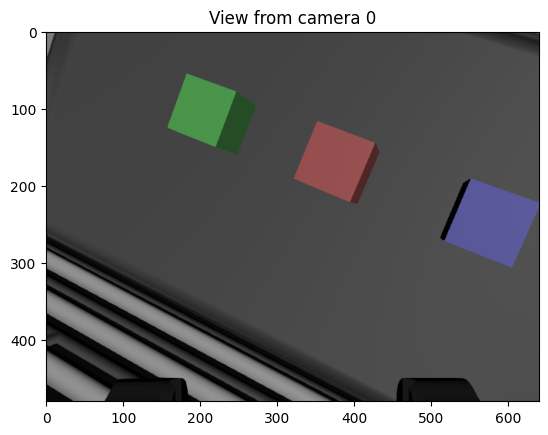

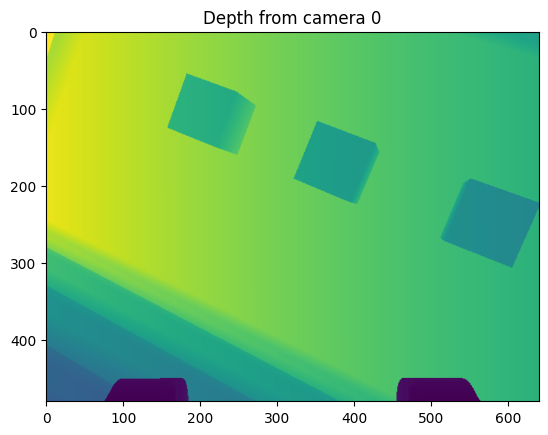

In [67]:
meshcat.Delete()
builder, station, plant, scene_graph, iiwa_vector_source = (
    create_bimanual_IIWA14_with_table_and_initials_and_assets_and_cameras()
)

# plant = station.GetSubsystemByName("plant")
# scene_graph = station.GetSubsystemByName("scene_graph")

# scene_graph = builder.AddSystem(SceneGraph())
# builder.Connect(plant.get_geometry_pose_output_port(), )

plant.Finalize()

AddRgbdSensors(builder, plant, scene_graph)
# for id in [0]:
#     builder.ExportOutput(plant.color_image_output_port(), f"camera{id}_rgb_image")
#     builder.ExportOutput(station.depth_image_output_port(), f"camera{id}_depth_image")

# in order to debug, we will build the diagram once here.
diagram = builder.Build()

# visualize the diagram
# RenderDiagram(diagram, max_depth=1)

# publish the diagram with some default context
diagram_context = diagram.CreateDefaultContext()
station_context = diagram.GetMutableSubsystemContext(station, diagram_context)

# plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.0)
# plant_context = diagram.GetMutableSubsystemContext(plant, diagram_context)

cameras = []
for id in [0]:
    cameras.append(CameraSystem(id, meshcat, diagram, diagram_context))

plant = station.GetSubsystemByName("plant")
plant_context = diagram.GetMutableSubsystemContext(plant, diagram_context)

cabinet = plant.GetModelInstanceByName("cabinet")
drawer_frame = plant.GetFrameByName("large_drawer_3", cabinet)
X_WD = plant.EvalBodyPoseInWorld(plant_context, drawer_frame.body())

local_positions = [
    np.array([0.00,  -0.10,  -0.15]),
    np.array([0.10,  -0.10,  -0.15]),
    np.array([-0.10, -0.10,  -0.15]),
]

for i, p_DB in enumerate(local_positions, start=1):
    box_model = plant.GetModelInstanceByName(f"box_{i}")
    box_body = plant.GetBodyByName("base", box_model)
    X_DB = RigidTransform(p_DB)
    X_WB = X_WD @ X_DB
    plant.SetFreeBodyPose(plant_context, box_body, X_WB)

# add_cameras(builder, plant, scene_graph, meshcat, diagram, diagram_context)

simulator = Simulator(diagram, diagram_context)
simulator.Initialize()
diagram.ForcedPublish(diagram_context)
dt = 2.0
# t = 0
# while t < end_time:
#     simulator.AdvanceTo(t + 1.0)
#     t += 1.0
#     meshcat.Flush()
simulator.AdvanceTo(dt)
t = dt

cameras[0].update_camera_feed()
cameras[0].update_camera_pos()

plt.imshow(cameras[0].rgb_im)
plt.title("View from camera 0")
plt.show()

plt.imshow(cameras[0].depth_im)
plt.title("Depth from camera 0")
plt.show()

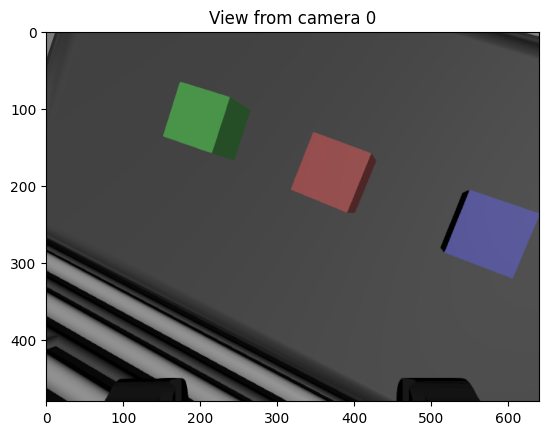

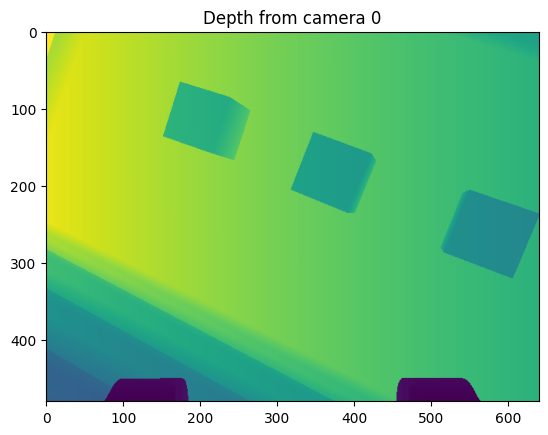

(480, 640, 3) (480, 640)
[[[125 125 125]
  [125 125 125]
  [125 125 125]
  ...
  [147 147 147]
  [148 148 148]
  [149 149 149]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  ...
  [143 143 143]
  [144 144 144]
  [145 145 146]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  ...
  [139 139 139]
  [140 140 140]
  [141 141 142]]

 ...

 [[  8   8   8]
  [  8   8   8]
  [  8   8   8]
  ...
  [ 77  77  77]
  [ 77  77  77]
  [ 77  77  77]]

 [[  8   8   8]
  [  8   8   8]
  [  8   8   8]
  ...
  [ 77  77  77]
  [ 77  77  77]
  [ 77  77  77]]

 [[  8   8   8]
  [  8   8   8]
  [  8   8   8]
  ...
  [ 77  77  77]
  [ 77  77  77]
  [ 77  77  77]]] [[0.43095958 0.43072584 0.43049237 ... 0.29012668 0.29000965 0.28989294]
 [0.43095958 0.43072584 0.43049267 ... 0.29012668 0.29000965 0.28989294]
 [0.43095958 0.43072614 0.43049267 ... 0.29012668 0.29000998 0.28989294]
 ...
 [0.20116273 0.20135096 0.2015395  ... 0.31271654 0.31259063 0.31246477]
 [0.20069344 0.20088081 0.20106845 ... 0.3127165

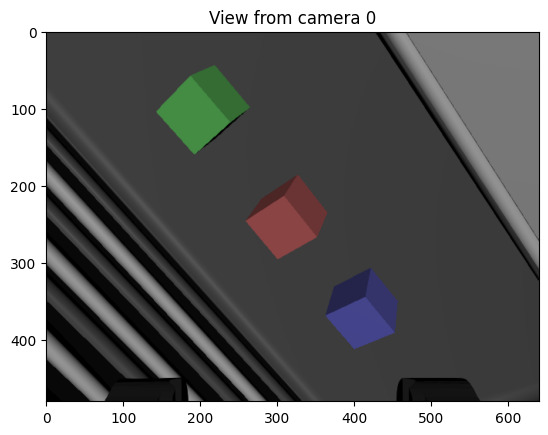

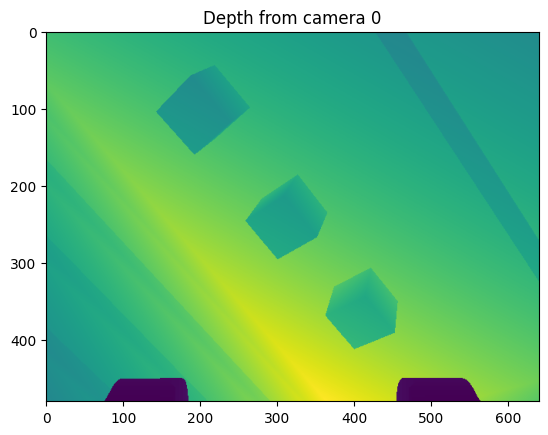

(480, 640, 3) (480, 640)
[[[ 62  62  62]
  [ 62  62  62]
  [ 62  62  62]
  ...
  [120 120 120]
  [120 120 120]
  [120 120 120]]

 [[ 62  62  62]
  [ 62  62  62]
  [ 62  62  62]
  ...
  [120 120 120]
  [120 120 120]
  [120 120 120]]

 [[ 62  62  62]
  [ 62  62  62]
  [ 62  62  62]
  ...
  [120 120 120]
  [120 120 120]
  [120 120 120]]

 ...

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [ 44  44  44]
  [ 44  44  44]
  [ 43  43  43]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [ 43  43  43]
  [ 42  42  42]
  [ 41  41  41]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [ 41  41  41]
  [ 40  40  40]
  [ 39  39  39]]] [[0.3830396  0.38284898 0.3826587  ... 0.29805675 0.29794416 0.2978319 ]
 [0.38338152 0.3831906  0.38299972 ... 0.29825887 0.298146   0.29803342]
 [0.38372403 0.38353282 0.3833416  ... 0.29846102 0.29834813 0.29823524]
 ...
 [0.2914698  0.29182145 0.2921737  ... 0.40491283 0.40443057 0.40394917]
 [0.29125822 0.29160926 0.29196125 ... 0.4043064

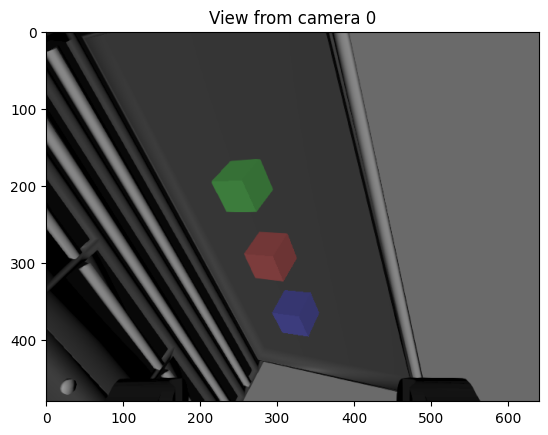

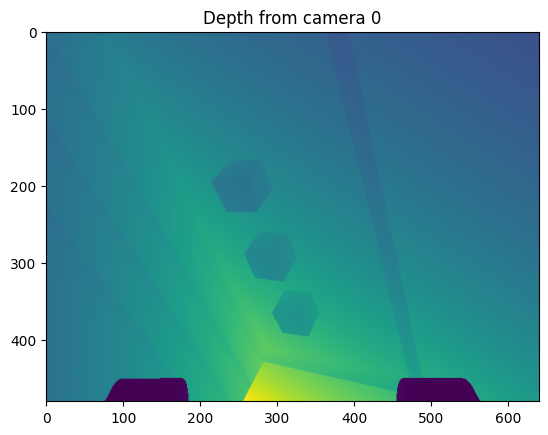

(480, 640, 3) (480, 640)
[[[ 37  37  37]
  [ 36  36  36]
  [ 35  35  35]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]

 [[ 34  34  34]
  [ 33  33  33]
  [ 32  32  32]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]

 [[ 32  32  32]
  [ 30  30  30]
  [ 29  29  29]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]

 ...

 [[ 57  57  57]
  [ 57  57  57]
  [ 57  57  57]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]

 [[ 56  56  56]
  [ 57  57  57]
  [ 57  57  57]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]

 [[ 56  56  56]
  [ 56  56  56]
  [ 57  57  57]
  ...
  [106 106 106]
  [106 106 106]
  [106 106 106]]] [[0.4327764  0.43343952 0.43410468 ... 0.32532457 0.32512924 0.32493418]
 [0.43279856 0.4334617  0.43412688 ... 0.32562926 0.32543334 0.325238  ]
 [0.4328204  0.43348354 0.43414876 ... 0.32593423 0.32573798 0.32554206]
 ...
 [0.4435339  0.44423047 0.44492903 ... 0.5872498  0.58661324 0.5859782 ]
 [0.44355696 0.44425347 0.44495237 ... 0.5882427

In [ ]:
dt = 2.0
q_checkpoints = np.array([[-3*np.pi/8.0, np.pi/4.0, 0.0, -2*np.pi/6.0, 0.0, 3*np.pi/6.0, np.pi/2.0],
                          [-3*np.pi/8.0+0.5, np.pi/4.0, 0.0, -2*np.pi/6.0, 0.0-0.5, 3*np.pi/6.0, np.pi/2.0],
                          [-3*np.pi/8.0+1.0, np.pi/4.0, 0.0, -2*np.pi/6.0, 0.0-0.7, 3*np.pi/6.0+0.2, np.pi/2.0],])

for q_cp in q_checkpoints:
    iiwa_vector_source_context = iiwa_vector_source.GetMyContextFromRoot(diagram_context)
    iiwa_vector_source.get_mutable_source_value(iiwa_vector_source_context).set_value(q_cp)
    simulator.AdvanceTo(t+dt)
    t += dt

    # get image + depth, as well as camera position
    cameras[0].update_camera_feed()
    cameras[0].update_camera_pos()

    rgb_im = cameras[0].rgb_im[:,:,:3] # [H,W,3]
    depth_im = cameras[0].depth_im #[H,W]
    camera_pos = cameras[0].X_WC

    plt.imshow(rgb_im)
    plt.title("View from camera 0")
    plt.show()

    plt.imshow(depth_im)
    plt.title("Depth from camera 0")
    plt.show()

    # print(rgb_im.shape, depth_im.shape)
    # print(rgb_im, depth_im)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0d36ce0d-4310-43b9-ad8c-5accad619245' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>